In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hikageshinomori/walmart-e-commerce-product-data/walmart.csv


***Walmart Product Performance Analysis***. *

**Step 0:Goal: Understand what factors affect product ratings and customer engagement**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#to ignore warnings
import warnings
warnings.filterwarnings('ignore')

df=pd.read_csv("/kaggle/input/datasets/hikageshinomori/walmart-e-commerce-product-data/walmart.csv")
df.head(4)

,title,url,brand,main_image,sku,description,gtin13,model,currency,price,...,sub_category_1,sub_category_2,images,specifications,directions,ingredients,avg_rating,reviews_count,uniq_id,scraped_at
0,Nuventin Anti-Wrinkle Retinol Cream with Hyalu...,https://www.walmart.com/ip/Nuventin-Anti-Wrink...,Nuventin,https://i5.walmartimages.com/asr/2d247025-a02e...,420971989,<p>Made with the number 1 recommended anti-agi...,8.104000e+11,NV001,USD,14.99,...,Bath & Body,Body Lotions,https://i5.walmartimages.com/asr/a8125edc-a1de...,"[{'name': 'Skin Type', 'value': 'All'}, {'name...",NaN,Water (Aqua) Mineral Oil Cetearyl Alcohol Glyc...,4.0,10.0,9131f420-2935-55c0-b112-7f67afd5e964,16/11/2022 23:21:34
1,DURASACK 48-Gallon Green Outdoor Polypropylene...,https://www.walmart.com/ip/DURASACK-48-Gallon-...,DURASACK®,https://i5.walmartimages.com/asr/e474980a-372c...,140920669,"DURASACK by Halsted - For hauling, cleaning, h...",6.532120e+11,BB-2028CTN,USD,17.99,...,Outdoor Power Equipment,Outdoor Power Equipment Parts and Accessories,https://i5.walmartimages.com/asr/4721180a-81fe...,[{'name': 'Assembled Product Dimensions (L x W...,NaN,NaN,4.9,31.0,8a7da806-be2c-57db-a064-305cd9097dec,16/11/2022 23:21:34
2,CE003-03-2 Ring sling Air-O size 2 AQUA Baby c...,https://www.walmart.com/ip/CE003-03-2-Ring-sli...,Chimparoo,https://i5.walmartimages.com/asr/617220d8-886d...,151317860,CE003-03-2 Ring sling Air-O size 2 AQUA Baby c...,8.745760e+11,NaN,USD,84.69,...,Baby Activities & Gear,Baby Carriers,https://i5.walmartimages.com/asr/617220d8-886d...,"[{'name': 'Brand', 'value': 'Chimparoo'}, {'na...",NaN,NaN,NaN,NaN,9609ca38-203e-5ddd-9552-6021c7f3e5a8,16/11/2022 23:21:35
3,"Monster Energy Java Monster Mean Bean, Coffee ...",https://www.walmart.com/ip/Monster-Energy-Java...,Monster Energy,https://i5.walmartimages.com/asr/a6c5940d-9995...,1145871245,"<br>Monster Energy Java Monster Mean Bean, Cof...",1.003784e+11,NaN,USD,41.99,...,Beverages,Energy Drinks,https://i5.walmartimages.com/asr/e6118707-f8fd...,"[{'name': 'Brand', 'value': 'Monster Energy'}]",NaN,NaN,NaN,NaN,eda2c112-68b1-5024-a62e-caa0181f03c9,16/11/2022 23:21:37




**Inspect data**

nunique() helps:

1. Identify column types
Categorical vs Continuous
ID vs Feature
2. Detect useless columns
Constant columns (only 1 value)
3. Understand data granularity
Product-level vs transaction-level


  2. Nature of the dataset

From the columns:

product info → title, brand, description
pricing → price
categories → primary_category, sub_category_1
reviews → avg_rating, reviews_count

So this is a:
Product-level dataset (NOT transactional data)

In [ ]:
df.nunique()

title                      500
url                        500
brand                      414
main_image                 499
sku                        500
description                490
gtin13                     351
model                      256
currency                     1
price                      386
availableDeliveryMethod      1
primary_category            19
sub_category_1              72
sub_category_2             203
images                     499
specifications             455
directions                  99
ingredients                 93
avg_rating                  23
reviews_count              105
uniq_id                    500
scraped_at                 405
dtype: int64

Using `nunique()`, we analyzed the number of unique values in each column to classify features into categorical, continuous, and identifier variables. Columns with fewer unique values, such as `primary_category`, were identified as categorical features suitable for grouping and segmentation. Columns like `price` and `reviews_count` with a large number of unique values were treated as continuous numerical variables.

Columns such as `title`, `sku`, and `uniq_id`, which have unique values nearly equal to the number of rows, were identified as identifier fields and are not useful for analysis. Additionally, columns with only one unique value, such as `currency`, were considered non-informative.

Overall, `nunique()` helped in understanding the dataset structure and identifying relevant features for further analysis.


Using nunique(), we analyzed the number of unique values in each column to classify features as categorical (low cardinality) or continuous (high cardinality). Additionally, duplicate records were inspected carefully to determine whether they represent data errors or meaningful repeated observations before deciding on removal.

In [ ]:
df.columns

Index(['title', 'url', 'brand', 'main_image', 'sku', 'description', 'gtin13',
       'model', 'currency', 'price', 'availableDeliveryMethod',
       'primary_category', 'sub_category_1', 'sub_category_2', 'images',
       'specifications', 'directions', 'ingredients', 'avg_rating',
       'reviews_count', 'uniq_id', 'scraped_at'],
      dtype='object')

In [ ]:
df.shape

(500, 22)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   title                    500 non-null    object 
 1   url                      500 non-null    object 
 2   brand                    500 non-null    object 
 3   main_image               500 non-null    object 
 4   sku                      500 non-null    int64  
 5   description              498 non-null    object 
 6   gtin13                   351 non-null    float64
 7   model                    257 non-null    object 
 8   currency                 499 non-null    object 
 9   price                    499 non-null    float64
 10  availableDeliveryMethod  500 non-null    object 
 11  primary_category         500 non-null    object 
 12  sub_category_1           500 non-null    object 
 13  sub_category_2           490 non-null    object 
 14  images                   5

In [ ]:
df.describe()

,sku,gtin13,price,avg_rating,reviews_count
count,5.000000e+02,3.510000e+02,499.000000,243.000000,243.00000
mean,6.211243e+08,5.010059e+11,26.082946,4.265844,356.81070
std,4.920216e+08,3.296772e+11,29.228484,0.918331,1369.14426
min,1.118745e+06,1.111102e+10,1.000000,1.000000,1.00000
25%,2.295070e+08,8.107358e+10,9.630000,4.050000,2.00000
50%,5.444722e+08,6.759061e+11,15.990000,4.600000,11.00000
75%,8.789888e+08,7.695769e+11,31.785000,4.900000,106.50000
max,2.739083e+09,9.435705e+11,249.000000,5.000000,13676.00000


The dataset contains 500 products and 22 columns, representing various attributes of Walmart e-commerce products.

From initial inspection (df.info, df.describe), the dataset includes both numerical and categorical features.

Key numerical columns identified:
- avg_rating → represents product quality
- reviews_count → represents customer engagement/popularity
- price → represents product pricing/value

Categorical columns include:
- brand → used to compare performance across brands
- primary_category, sub_category → used for product segmentation

Data quality observations:
- avg_rating and reviews_count have only 243 non-null values (~50% missing)
- price is mostly complete (499 non-null values)
- Several columns such as url, image, description, and sku are not relevant for performance analysis

Conclusion:
The dataset contains relevant features to analyze product performance, but missing values in key metrics (avg_rating and reviews_count) must be handled before proceeding with analysis.

Data Quality checks

In [ ]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
495    False
496    False
497    False
498    False
499    False
Length: 500, dtype: bool

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
##Check missing values per column

df.isnull().sum()

title                        0
url                          0
brand                        0
main_image                   0
sku                          0
description                  2
gtin13                     149
model                      243
currency                     1
price                        1
availableDeliveryMethod      0
primary_category             0
sub_category_1               0
sub_category_2              10
images                       0
specifications              33
directions                 394
ingredients                404
avg_rating                 257
reviews_count              257
uniq_id                      0
scraped_at                   0
dtype: int64

In [ ]:
#percentage of missing values
(df.isnull().sum() / len(df)) * 100

title                       0.0
url                         0.0
brand                       0.0
main_image                  0.0
sku                         0.0
description                 0.4
gtin13                     29.8
model                      48.6
currency                    0.2
price                       0.2
availableDeliveryMethod     0.0
primary_category            0.0
sub_category_1              0.0
sub_category_2              2.0
images                      0.0
specifications              6.6
directions                 78.8
ingredients                80.8
avg_rating                 51.4
reviews_count              51.4
uniq_id                     0.0
scraped_at                  0.0
dtype: float64

In [ ]:
df.replace(["", "NA", "null", "None"], pd.NA, inplace=True)
df.isnull().sum()

title                        0
url                          0
brand                        0
main_image                   0
sku                          0
description                  2
gtin13                     149
model                      243
currency                     1
price                        1
availableDeliveryMethod      0
primary_category             0
sub_category_1               0
sub_category_2              10
images                       0
specifications              33
directions                 394
ingredients                404
avg_rating                 257
reviews_count              257
uniq_id                      0
scraped_at                   0
dtype: int64

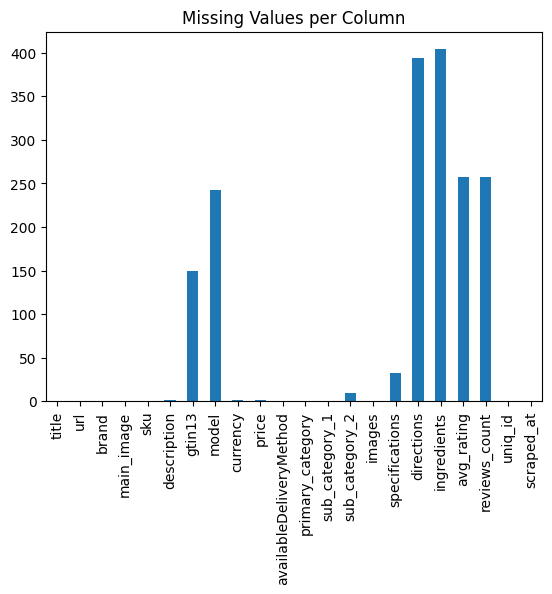

In [ ]:
#Visualization – for understanding quickly

df.isnull().sum().plot(kind='bar')
plt.title("Missing Values per Column")
plt.show()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#View duplicate rows
df[df.duplicated()]

,title,url,brand,main_image,sku,description,gtin13,model,currency,price,...,sub_category_1,sub_category_2,images,specifications,directions,ingredients,avg_rating,reviews_count,uniq_id,scraped_at


In [ ]:
df.dtypes

title                       object
url                         object
brand                       object
main_image                  object
sku                          int64
description                 object
gtin13                     float64
model                       object
currency                    object
price                      float64
availableDeliveryMethod     object
primary_category            object
sub_category_1              object
sub_category_2              object
images                      object
specifications              object
directions                  object
ingredients                 object
avg_rating                 float64
reviews_count              float64
uniq_id                     object
scraped_at                  object
dtype: object

The dataset was evaluated for data quality issues including duplicates, missing values, and data types.

- No duplicate records were found.
- Significant missing values were observed in avg_rating and reviews_count (~51%), which are critical for measuring product performance.
- Price and categorical columns such as brand and primary_category are mostly complete and reliable.
- Several columns such as ingredients and directions contain excessive missing values and are not relevant for the analysis.

Conclusion:
Rows with missing values in avg_rating and reviews_count will be removed to ensure accurate and reliable analysis.

Data cleaning and Imputation**

In [ ]:
# Drop rows with missing core metrics
#Keeping the columns
#Removing rows where these columns have missing values
df_clean = df.dropna(subset=["avg_rating", "reviews_count"])


# Handling price
df_clean["price"] = df_clean["price"].fillna(df_clean["price"].median())
df_clean

,title,url,brand,main_image,sku,description,gtin13,model,currency,price,...,sub_category_1,sub_category_2,images,specifications,directions,ingredients,avg_rating,reviews_count,uniq_id,scraped_at
0,Nuventin Anti-Wrinkle Retinol Cream with Hyalu...,https://www.walmart.com/ip/Nuventin-Anti-Wrink...,Nuventin,https://i5.walmartimages.com/asr/2d247025-a02e...,420971989,<p>Made with the number 1 recommended anti-agi...,8.104000e+11,NV001,USD,14.99,...,Bath & Body,Body Lotions,https://i5.walmartimages.com/asr/a8125edc-a1de...,"[{'name': 'Skin Type', 'value': 'All'}, {'name...",NaN,Water (Aqua) Mineral Oil Cetearyl Alcohol Glyc...,4.0,10.0,9131f420-2935-55c0-b112-7f67afd5e964,16/11/2022 23:21:34
1,DURASACK 48-Gallon Green Outdoor Polypropylene...,https://www.walmart.com/ip/DURASACK-48-Gallon-...,DURASACK®,https://i5.walmartimages.com/asr/e474980a-372c...,140920669,"DURASACK by Halsted - For hauling, cleaning, h...",6.532120e+11,BB-2028CTN,USD,17.99,...,Outdoor Power Equipment,Outdoor Power Equipment Parts and Accessories,https://i5.walmartimages.com/asr/4721180a-81fe...,[{'name': 'Assembled Product Dimensions (L x W...,NaN,NaN,4.9,31.0,8a7da806-be2c-57db-a064-305cd9097dec,16/11/2022 23:21:34
4,Comforter set matching fitted sheet set and pi...,https://www.walmart.com/ip/Comforter-set-match...,SAMIMPORT-2011,https://i5.walmartimages.com/asr/d42d61c8-3423...,907696530,It’s important you help them build a comfortab...,6.906841e+11,NaN,USD,45.00,...,Toddlers' Room,Toddler Bedding,https://i5.walmartimages.com/asr/52fa07d0-b7be...,"[{'name': 'Assembled Product Weight', 'value':...",*gentle cycle *tumble dry low *do not bleach *...,NaN,4.3,23.0,5b17cebf-6789-5327-91dc-d04d8cc3691c,16/11/2022 23:21:37
5,Bestgoods Large Capacity Stroller Straps Inclu...,https://www.walmart.com/ip/Bestgoods-Large-Cap...,Bestgoods,https://i5.walmartimages.com/asr/9145b84d-396f...,593176461,<p>Large Capacity Baby Bag: Gray diaper bag ba...,NaN,NaN,USD,43.99,...,Diapering,Diaper Bags,https://i5.walmartimages.com/asr/6d000d62-877e...,"[{'name': 'Features', 'value': 'Changing Pad I...",NaN,NaN,5.0,3.0,06acee21-88e2-5457-9c63-2745b40fca95,16/11/2022 23:21:37
9,Winfun Multi Color Grow With Me Melody Gym - G...,https://www.walmart.com/ip/Winfun-Multi-Color-...,WinFun,https://i5.walmartimages.com/asr/d90b6653-bf55...,55684970,Winfun Grow With me Multi Color Melody Gym is ...,8.401720e+11,0822WF,USD,52.00,...,Baby Activities & Gear,Baby Gyms & Playmats,https://i5.walmartimages.com/asr/5e4543e7-1ac3...,"[{'name': 'Features', 'value': '3 AA (included...",NaN,NaN,4.3,6.0,0ee68691-ca4c-5332-879b-7ad8a44cad6b,16/11/2022 23:21:40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488,Babo Botanicals - Miracle Moisturizing Cream,https://www.walmart.com/ip/Babo-Botanicals-Mir...,Babo Botanicals,https://i5.walmartimages.com/asr/841d7e55-ce66...,49355392,For sensitive or dry skin leaves skin incredib...,8.992480e+11,1632298,USD,13.52,...,Bath & Body,Body Lotions,https://i5.walmartimages.com/asr/f27f43b9-24ff...,"[{'name': 'Features', 'value': 'Babo Botanical...",Directions: For general use and intensive mois...,"Water (Aqua), (Aloe Barbadensis Leaf Juice), C...",4.7,32.0,28e10ca6-9ca9-5383-9067-cab5bf690915,16/11/2022 23:38:37
489,BEARD CUT THROAT BUMP FREE DOUBLE EDGE SAFETY ...,https://www.walmart.com/ip/BEARD-CUT-THROAT-BU...,Zeepk,https://i5.walmartimages.com/asr/39bf8b01-bf85...,763028877,Double Edge Safety RazorMade of Stainless Stee...,6.165566e+11,NaN,USD,12.99,...,Shaving,Men's Razors and Razor Blades,https://i5.walmartimages.com/asr/108d6fe1-d31c...,"[{'name': 'Brand', 'value': 'Zeepk'}]",NaN,NaN,4.0,1.0,1e45a2f4-b1fb-574f-8ad4-0a1324020eb5,16/11/2022 23:38:39
491,"Liquid Hand Soap, 1 Gallon Bottle, 4/Bottles",https://www.walmart.com/ip/Liquid-Hand-Soap-1-...,Global Industrial,https://i5.walmartimages.com/asr/7b079696-cd27...,230130246,"Ideal for use in schools, industry, lodging, a...",7.070221e+11,NaN,USD,58.41,...,Bath & Body,Hand So

In [ ]:
#verifying
df.shape
df_clean.shape

(243, 22)

In [ ]:
df_clean["avg_rating"].isnull().sum()
df_clean["reviews_count"].isnull().sum()

np.int64(0)

Data cleaning was performed to ensure reliable analysis.

- Rows with missing values in avg_rating and reviews_count were removed,
  as these are key metrics for evaluating product performance.

- Missing values in price were minimal and were imputed using the median.

- The cleaned dataset now contains only valid and complete records
  for further analysis.

However, this ensures that the analysis is based only on reliable and valid data,
even though it may reduce the overall sample size.

avg_rating → Quality (customer satisfaction)
reviews_count → Popularity (engagement)
price → Value (positioning)

**Analysis**

Understand how rating, reviews, and price are distributed
and how they behave before doing detailed analysis.

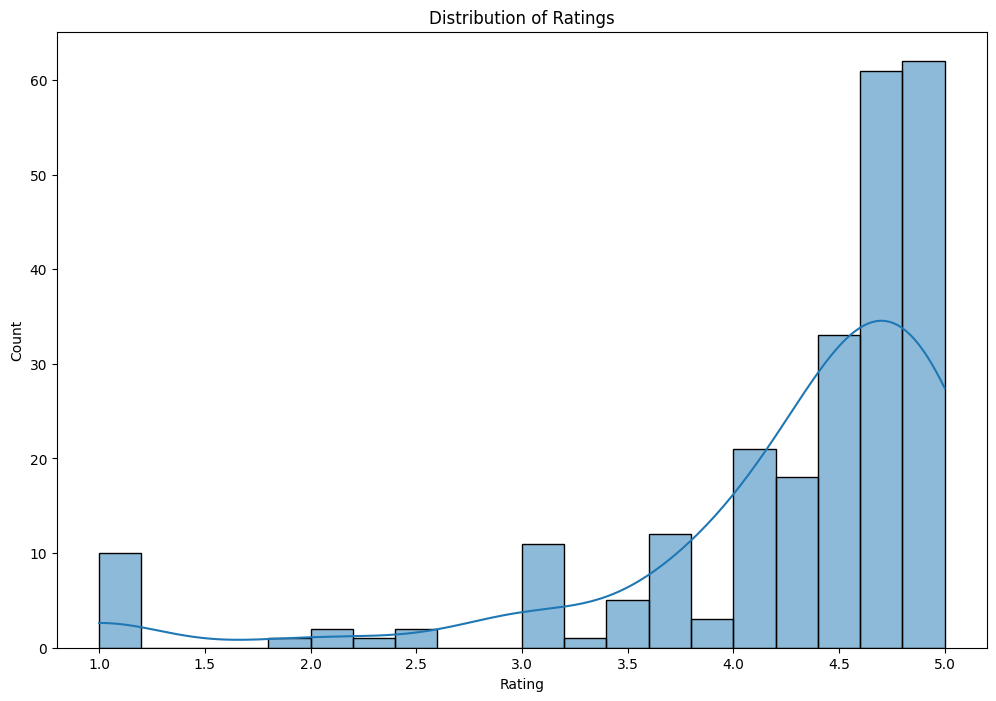

In [ ]:
plt.figure(figsize=(12,8))
sns.histplot(data=df_clean,x="avg_rating",bins=20,kde=True,edgecolor="black")
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

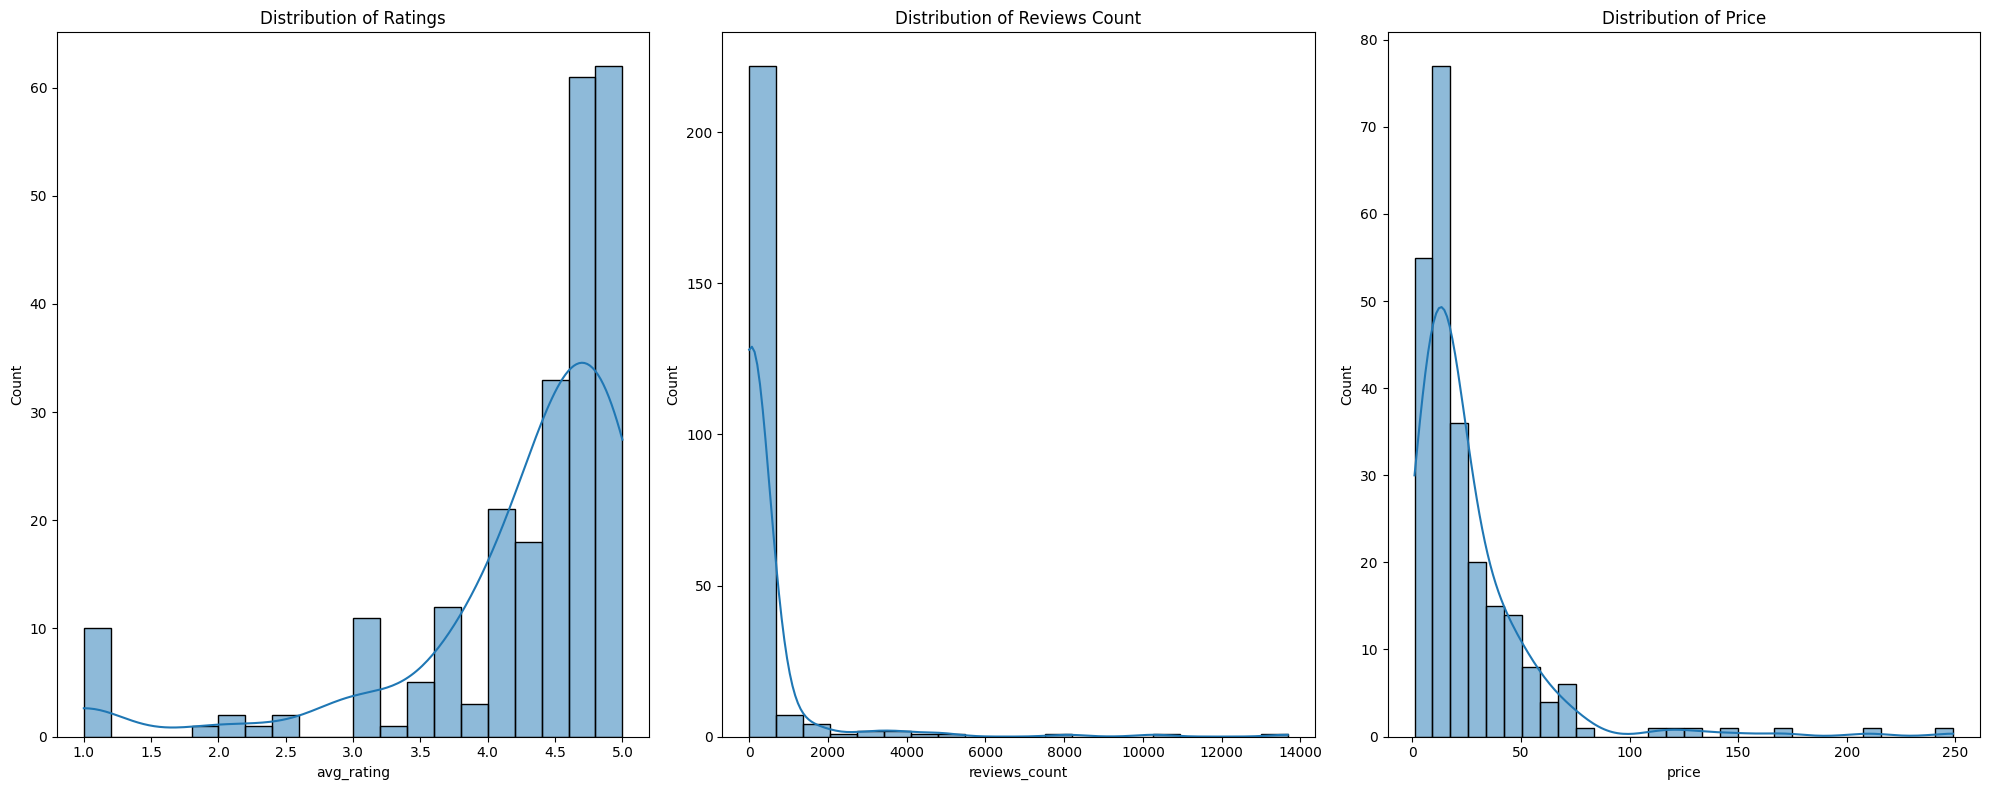

In [ ]:
plt.figure(figsize=(20,8))
plt.subplot(1,3,1)
sns.histplot(data=df_clean,x="avg_rating",bins=20,kde=True)
plt.title("Distribution of Ratings")

plt.subplot(1,3,2)
sns.histplot(data=df_clean,x="reviews_count",bins=20,kde=True)
plt.title("Distribution of Reviews Count")

plt.subplot(1,3,3)
sns.histplot(data=df_clean,x="price",bins=30,kde=True)
plt.title("Distribution of Price")

plt.tight_layout()
plt.show()


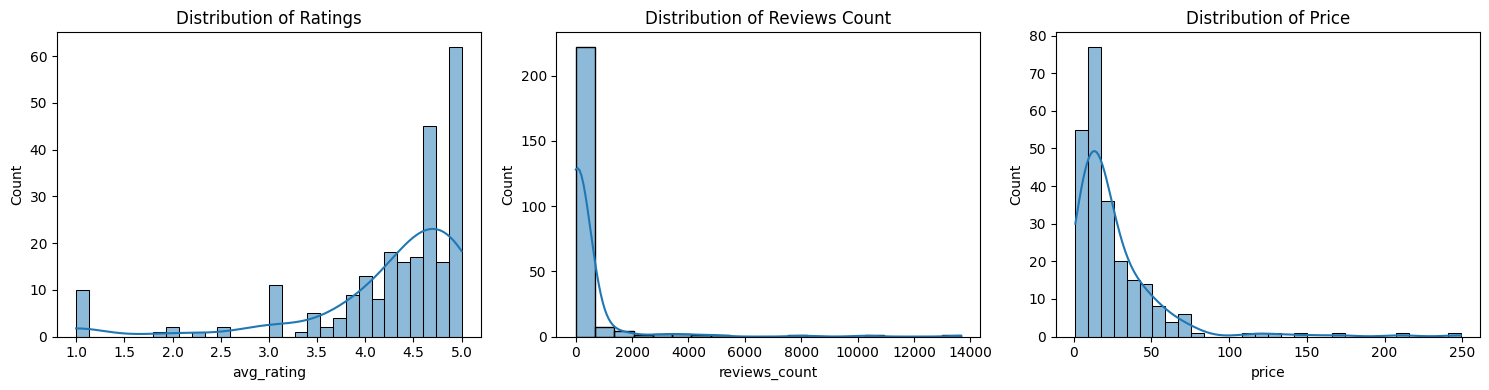

In [ ]:
# fig,axes=plt.subplots(1,3,figsize=(15,4))

# sns.histplot(data=df_clean,x="avg_rating",ax=axes[0],bins=30,kde=True)
# axes[0].set_title("Distribution of Ratings")

# sns.histplot(data=df_clean,x="reviews_count",ax=axes[1],bins=20,kde=True)
# axes[1].set_title("Distribution of Reviews Count")

# sns.histplot(data=df_clean,x="price",ax=axes[2],bins=30,kde=True)
# axes[2].set_title("Distribution of Price")

# plt.tight_layout()
# plt.show()

**avg_rating**

The distribution of avg_rating is left-skewed, with most products having ratings between 4.5 and 5.0.

There are a few low-rated products, indicating that customer satisfaction is generally high.

**reviews_count**
The distribution of reviews_count is highly right-skewed, with most products having low review counts and a few products having extremely high values.

This indicates that customer engagement is concentrated among a small number of products.

**price**

The distribution of price is right-skewed, with most products priced in the lower to mid range and a few high-priced outliers.

This suggests that the majority of products are affordable, with limited premium offerings.




**Bivariate AnalysisQuestion:Do higher-rated products get more reviews?**


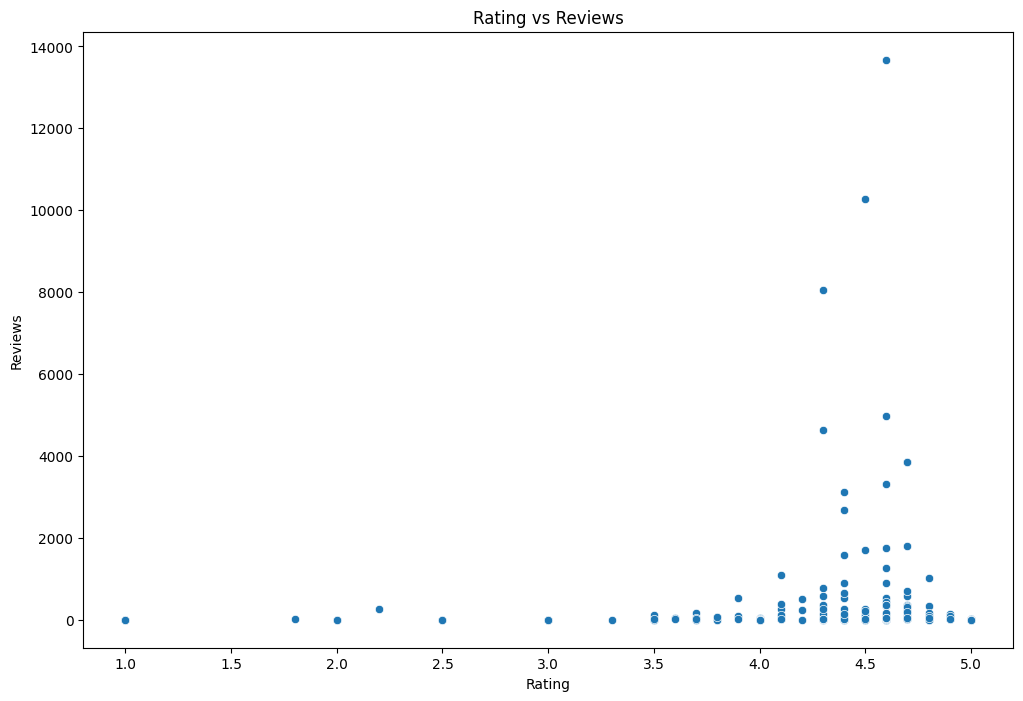

In [ ]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=df_clean,x="avg_rating",y="reviews_count")
plt.title("Rating vs Reviews")
plt.xlabel("Rating")
plt.ylabel("Reviews")
plt.show()

This scatter plot shows the relationship between average rating and review count. The points are widely scattered, indicating no strong correlation between the variables. A cluster of observations is concentrated between ratings of 4 and 5 with relatively low review counts. Additionally, there is high variability in review counts for similar rating values, and a few outliers with very high review counts are observed.

In terms of business
There is no strong relationship between average rating and review count, indicating that higher-rated products do not necessarily receive more customer engagement.

Most products have high ratings but low review counts, while a small number of products receive significantly higher reviews.

This suggests that product popularity is not driven solely by ratings, and other factors play a key role in customer engagement.

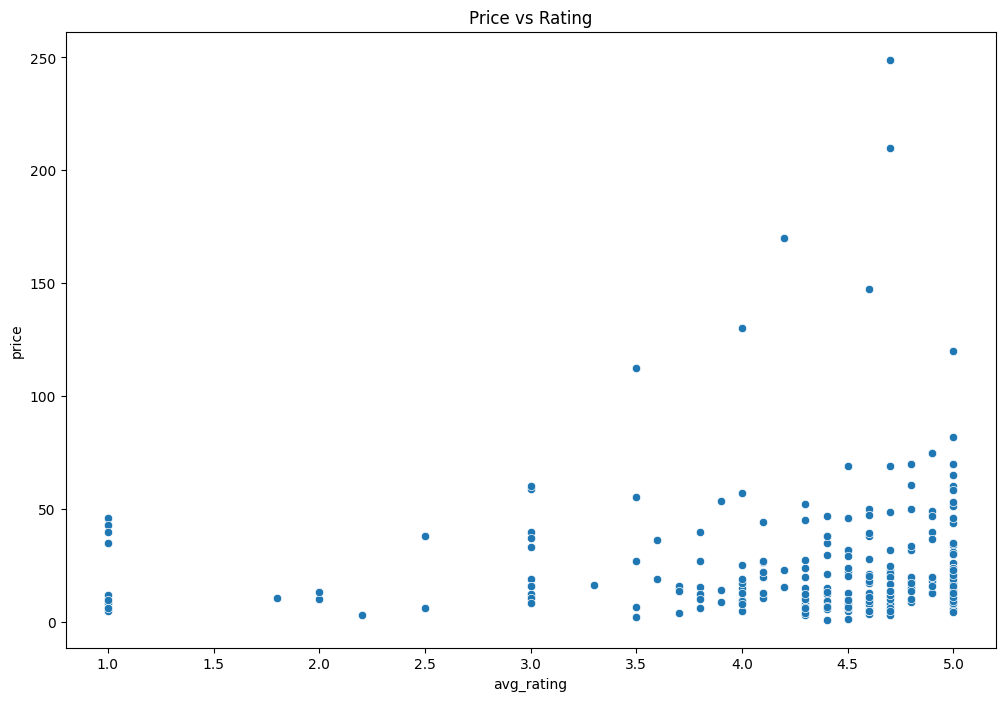

In [ ]:
plt.figure(figsize=(12,8))
sns.scatterplot(x="avg_rating", y="price", data=df_clean)
plt.title("Price vs Rating")
plt.xlabel("avg_rating")
plt.ylabel("price")
plt.show()


**The scatter plot shows no strong relationship between average rating and price, with points widely scattered across the graph.Most products are clustered between ratings of 4.0 and 5.0 across a wide range of prices, indicating that both low-priced and high-priced products tend to receive similarly high ratings.There is significant variability in price for similar rating values, and a few high-priced outliers are observed.Overall, this suggests that product price does not strongly influence customer satisfaction, and more expensive products are not necessarily rated higher.**


**Multivariate analysis**

**Category level performance**


In [ ]:
category_perf =df_clean.groupby("primary_category")[["avg_rating","reviews_count"]].mean().sort_values(by="avg_rating",ascending=False)
category_perf

,avg_rating,reviews_count
primary_category,,
Party & Occasions,4.866667,6.666667
Office Supplies,4.800000,34.000000
Health and Medicine,4.766667,338.000000
Sports & Outdoors,4.500000,115.000000
Toys,4.450000,35.000000
Premium Beauty,4.437500,17.875000
Beauty,4.420833,844.458333
Pets,4.400000,119.000000
Personal Care,4.335385,491.046154


**The table shows the average rating and review count across different product categories. While some categories such as Party & Occasions have very high ratings, they have relatively low review counts. In contrast, categories like Beauty have slightly lower ratings but significantly higher review counts. This indicates that higher ratings do not necessarily correspond to higher customer engagement.**


**Brand-Level Analysis:
Which brands have the highest ratings and engagement?**


In [ ]:
brand_perf=df_clean.groupby("brand")[["avg_rating","reviews_count"]].mean().sort_values(by="avg_rating",ascending=False)
brand_perf

,avg_rating,reviews_count
brand,,
Alpine Industries,5.0,4.0
AsaVea,5.0,1.0
Bee's Wrap,5.0,3.0
Bloomingmore,5.0,1.0
Bikini Zone,5.0,1.0
...,...,...
Bad Piggies,1.0,1.0
Surker,1.0,1.0
Sufanic,1.0,1.0


 Key insight:

Ratings look extreme (1 or 5)

But reviews are very low

Data is not stable



**The actual problem name (important) This is called: Sample Size Bias / Small Sample Problem**






1))Case 1: Unstable (your data)
Brand A → rating = 5.0
reviews = 1

Only one person rated it

That 5.0 could easily change

Case 2: Stable
Brand B → rating = 4.5
reviews = 1000

Many people rated it

More reviews = more reliable rating
Fewer reviews = unstable / unreliable rating


2))Many brands → rating 5.0
reviews → 1, 2, 3



These ratings are based on very little data
They can change easily



The table shows the average rating and review count across different brands. Many brands have very high ratings but very low review counts, suggesting that these ratings may not be reliable due to limited customer feedback. Additionally, there is no consistent relationship between rating and engagement across brands.

In [ ]:
#  2. Weighted Score (BEST METHOD )

#  Combine rating + reviews

brand_perf = df_clean.groupby("brand")[["avg_rating","reviews_count"]].mean()

brand_perf["weighted_score"] = (
    brand_perf["avg_rating"] * brand_perf["reviews_count"]
)

brand_perf.sort_values(by="weighted_score", ascending=False)

# High rating + high reviews = strong performance
# Low reviews = low weight

,avg_rating,reviews_count,weighted_score
brand,,,
affresh,4.6,13676.0,62909.6
Native,4.5,10284.0,46278.0
Dove,4.3,4642.0,19960.6
Glad,4.7,3864.0,18160.8
Maybelline,4.1,4300.0,17630.0
...,...,...,...
Bad Piggies,1.0,1.0,1.0
Surker,1.0,1.0,1.0
Sufanic,1.0,1.0,1.0


1. Problem Statement

During the analysis of brand performance, it was observed that several brands had very high average ratings despite having very low review counts. This indicates that the mean rating alone may be misleading, as it does not account for the number of observations contributing to the average. Ratings based on very few reviews are not reliable and can distort comparisons across brands.

2. Approach / Solution

To address this issue, multiple approaches were considered:

Minimum Reviews Filter: Brands with very low review counts were excluded to ensure that only reliable data was considered.
Weighted Scoring Method: A weighted score was calculated by combining average rating and review count. This approach prioritizes brands that have both high ratings and strong customer engagement.
Bayesian Adjustment (Conceptual): An advanced statistical method that adjusts ratings based on the overall average and sample size was considered to reduce bias from small datasets.

For this analysis, the weighted scoring approach was selected as it provides a balance between simplicity and effectiveness.

3. Final Implementation
The final analysis used a weighted scoring method to rank brands based on both rating quality and engagement level. This helps ensure that brands with high ratings supported by a large number of reviews are prioritized over those with high ratings based on limited data.

In [ ]:
brand_perf = df_clean.groupby("brand")[["avg_rating","reviews_count"]].mean()

brand_perf["performance_score"] = (
    brand_perf["avg_rating"] * brand_perf["reviews_count"]
)

brand_perf.sort_values(by="performance_score", ascending=False)

,avg_rating,reviews_count,performance_score
brand,,,
affresh,4.6,13676.0,62909.6
Native,4.5,10284.0,46278.0
Dove,4.3,4642.0,19960.6
Glad,4.7,3864.0,18160.8
Maybelline,4.1,4300.0,17630.0
...,...,...,...
Bad Piggies,1.0,1.0,1.0
Surker,1.0,1.0,1.0
Sufanic,1.0,1.0,1.0


To improve the weighted scoring approach, a logarithmic transformation was applied to the review count. This reduces the impact of extremely high review values, ensuring that brands with very large review counts do not dominate the ranking. As a result, the performance score provides a more balanced representation of both rating quality and customer engagement.

A logarithmic scaling was applied to review counts to prevent brands with very high reviews from dominating the results.

In [ ]:
import numpy as np

brand_perf["performance_score"] = (
    brand_perf["avg_rating"] * np.log1p(brand_perf["reviews_count"])
)
brand_perf.sort_values(by="performance_score", ascending=False)

brand_perf["performance_score"]

brand
9 Elements      24.625218
AURORA TRADE     3.295837
Air Wick        10.818649
Alayna           7.880936
Aleve           33.200232
                  ...    
happylost17      3.465736
iMounTEK         6.808686
prabensei        9.729551
windfall         0.693147
zhongxinda       5.493061
Name: performance_score, Length: 213, dtype: float64

## Brand Performance Analysis Using Weighted Scoring

### Problem Statement

During the initial analysis of brand performance, it was observed that several brands had very high average ratings despite having very low review counts. Since the mean rating does not consider the number of observations, this can lead to misleading conclusions. Ratings based on a small number of reviews are not reliable indicators of true brand performance.

### Approach

To address this limitation, a weighted scoring approach was implemented. Instead of relying solely on average rating, the analysis incorporates both rating and review count. Additionally, a logarithmic transformation was applied to the review count to control the impact of extremely large values and ensure a balanced comparison.

### Methodology

A performance score was computed using the following formula:

Performance Score = Average Rating × log(1 + Review Count)

This approach ensures:

* Brands with high ratings and sufficient reviews are prioritized
* Brands with very few reviews do not appear artificially superior
* Extremely high review counts do not dominate the ranking

### Implementation

The following code was used:

```python
import numpy as np

brand_perf = df_clean.groupby("brand")[["avg_rating","reviews_count"]].mean()

brand_perf["performance_score"] = (
    brand_perf["avg_rating"] * np.log1p(brand_perf["reviews_count"])
)

brand_perf = brand_perf.sort_values(by="performance_score", ascending=False)
```

### Results and Interpretation

The resulting performance scores provide a more balanced evaluation of brand performance by combining both product quality and customer engagement. Brands with high scores represent those that are not only highly rated but also supported by a significant number of reviews.

### Key Insight

The analysis shows that high ratings alone are not sufficient to evaluate brand performance. Brands must also demonstrate consistent customer engagement to be considered reliable. The weighted scoring method ensures a more realistic and fair ranking of brands.

### Conclusion

By incorporating review count and applying logarithmic scaling, the analysis overcomes the limitations of simple averages. This approach aligns with real-world analytical practices and provides a more robust measure of brand performance.


### Insights


Most Walmart products have ratings between 4 and 5, indicating generally high customer satisfaction.
Customer engagement is highly uneven, with a small number of products receiving the majority of reviews and attention.
There is no strong relationship between product ratings and review counts, suggesting that highly rated products are not necessarily the most popular.
There is no significant relationship between price and ratings, indicating that higher-priced products are not always perceived as better by customers.
Product performance varies across categories, with some categories showing high engagement while others achieve higher ratings.
Several brands appeared to have perfect ratings, but these ratings were based on very few reviews, making them unreliable indicators of performance.
A weighted performance score was introduced to address the small-sample bias by considering both customer ratings and review counts.
Using the weighted scoring approach, brands such as affresh, Native, and Dove emerged as the strongest performers due to their combination of high customer satisfaction and strong engagement.
Overall, product success on Walmart is driven by a combination of quality (ratings) and engagement (reviews) rather than ratings alone.

**Recommendation**

Recommendation 1: Increase Visibility of High-Quality Products

The analysis revealed that several products receive high customer ratings but relatively low customer engagement. Walmart should increase the visibility of these products through featured placements, personalized recommendations, and promotional campaigns. This can help attract additional customer attention and encourage greater engagement with products that already demonstrate strong customer satisfaction.

Recommendation 2: Use Weighted Metrics for Product and Brand Evaluation

Average ratings alone may provide a misleading view of performance when review counts are low. Walmart should adopt weighted performance metrics that combine ratings and review counts when evaluating products and brands. This will provide a more reliable measure of performance by considering both customer satisfaction and customer engagement.

Recommendation 3: Leverage Insights from Top-Performing Products

Since customer engagement is concentrated among a small number of products, Walmart should analyze the characteristics of top-performing products and apply similar marketing, placement, and promotional strategies to other products. This can help increase engagement across a wider range of products.

Recommendation 4: Focus on Product Value Rather Than Price

As higher-priced products do not consistently receive better ratings, Walmart should prioritize improving product quality, customer experience, and perceived value rather than relying primarily on pricing strategies to influence customer satisfaction.

**Conclusion**


The analysis demonstrates that product performance on Walmart is driven by a combination of customer satisfaction and customer engagement rather than ratings alone. While most products receive high ratings, customer engagement is concentrated among a small number of products. Additionally, price does not appear to significantly influence customer satisfaction. By incorporating weighted performance metrics that account for both ratings and review counts, a more reliable assessment of product and brand performance was achieved, enabling better identification of top-performing products and brands.